<center><h1>CS60216: Safety Fundamentals for Generative AI</h1></center>
<center><h2>Safety Alignment of LLMs: Parameter Space vs. Activation Space Interventions</h2></center>
<center><h3>Anirvan Krishna | 21EE38002 </h3></center>

# Supervised Fine-tuning and DARE

In [1]:
!pip install sacrebleu evaluate tabulate mergekit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.7/431.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 58.4 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successf

# Instruction Finetuning

In [ ]:
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from transformers import AutoTokenizer, AutoModelForCausalLM

from mergekit.config import MergeConfiguration
from mergekit.merge import MergeOptions, run_merge

import os
import shutil
import evaluate
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from huggingface_hub import login

In [ ]:
HF_TOKEN = "[YOUR_HF_TOKEN]"
login(HF_TOKEN)

In [4]:
torch.manual_seed(0)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Model loading
We are using [Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct) for the supervised finetuning on the [Medical Maeadow: MedQA Dataset](https://huggingface.co/datasets/medalpaca/medical_meadow_medqa)

In [6]:
qwen_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct",
                                                  dtype=torch.float16, device_map="auto")

qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token
    qwen_model.config.pad_token_id = qwen_tokenizer.eos_token_id
    qwen_tokenizer.padding_side = "right"

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Dataset Preparation
We will use the first 60% of the dataset for training, and the next 20% each for validation and testing

In [7]:
dataset = load_dataset("medalpaca/medical_meadow_medqa")

# Split the dataset into training, validation, and test sets without shuffling
len_train = int(0.6 * len(dataset["train"]))
len_val = int(0.2 * len(dataset["train"]))
len_test = int(0.2 * len(dataset["train"]))

train_dataset = dataset["train"].select(range(len_train))
val_dataset = dataset["train"].select(range(len_train, len_train + len_val))
test_dataset = dataset["train"].select(range(len_train + len_val, len_train + len_val + len_test))

train_dataset

README.md: 0.00B [00:00, ?B/s]

medical_meadow_medqa.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Dataset({
    features: ['input', 'instruction', 'output'],
    num_rows: 6106
})

#### Instruction Finetuning Configuration

To prepare the dataset for finetuning, we combine the **Instruction** and the **Input** into a unified string.

**Standard Template**
> **Format:** `Instruction` + `[Empty Line]` + `Input`

---

#### Example Implementation

```diff
+ Please answer with one of the options in the bracket.

- Q: A 23-year-old pregnant woman at 22 weeks gestation presents with
- burning upon urination...

- Which of the following is the best treatment for this patient?
```

In [8]:
def format_prompt(example):
    prompts = []
    full_texts = []

    for i in range(len(example['instruction'])):
        # 1. The prompt (Everything up to the assistant's turn)
        prompt = (
            f"<|im_start|>user\n"
            f"{example['instruction'][i]}\n"
            f"{example['input'][i]}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )
        # 2. The full sequence (Prompt + Output)
        full_text = prompt + f"{example['output'][i]}<|im_end|>"

        prompts.append(prompt)
        full_texts.append(full_text)

    return {"prompt": prompts, "full_text": full_texts}

In [9]:
train_dataset = train_dataset.map(format_prompt, batched=True)
val_dataset = val_dataset.map(format_prompt, batched=True)
test_dataset = test_dataset.map(format_prompt, batched=True)

train_dataset.set_format(type="torch", columns=["prompt", "full_text"])
val_dataset.set_format(type="torch", columns=["prompt", "full_text"])
test_dataset.set_format(type="torch", columns=["prompt", "full_text"])

Map:   0%|          | 0/6106 [00:00<?, ? examples/s]

Map:   0%|          | 0/2035 [00:00<?, ? examples/s]

Map:   0%|          | 0/2035 [00:00<?, ? examples/s]

In [10]:
train_dataset[0]

{'prompt': "<|im_start|>user\nPlease answer with one of the option in the bracket\nQ:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?? \n{'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Ciprofloxacin', 'D': 'Doxycycline', 'E': 'Nitrofurantoin'},<|im_end|>\n<|im_start|>assistant\n",
 'full_text': "<|im_start|>user\nPlease answer with one of the option in the bracket\nQ:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She stat

In [11]:
BATCH_SIZE = 8

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8)
test_dataloader = DataLoader(test_dataset, batch_size=8)

In [12]:
batch = next(iter(train_dataloader))

print("Example Prompt:")
print(batch['prompt'][0])

print("Example Full Text:")
print(batch['full_text'][0])

Example Prompt:
<|im_start|>user
Please answer with one of the option in the bracket
Q:A 3-year-old boy is brought to the physician by his parents for the evaluation of easy bruising for several months. Minor trauma also causes scratches that bleed. Two months ago, a fall from his bed caused a large forehead hematoma and a left elbow laceration. He sometimes does not eat because of pain while chewing. Vital signs are within normal limits. Examination shows that the skin can be stretched further than normal and is fragile. Range of motion of the joints is slightly increased. There is tenderness to palpation of the temporomandibular joints bilaterally. Which of the following is the most likely underlying cause of this patient's symptoms?? 
{'A': 'Impaired copper absorption', 'B': 'Factor VIII deficiency', 'C': 'Defective type III collagen', 'D': 'Defective type V collagen', 'E': 'Defective type I collagen\n"'},<|im_end|>
<|im_start|>assistant

Example Full Text:
<|im_start|>user
Please a

### Low-Rank Adapters (LoRA) Finetuning

In [13]:
LoRA_RANK = 8
LoRA_ALPHA = 64
LoRA_DROPOUT = 0.05
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5

lora_config = LoraConfig(
    r=LoRA_RANK,
    lora_alpha=LoRA_ALPHA,
    lora_dropout=LoRA_DROPOUT,
    init_lora_weights="gaussian",
    target_modules=["q_proj", "k_proj", "v_proj"],
    task_type=TaskType.CAUSAL_LM,
)

qwen_model = get_peft_model(qwen_model, lora_config)
qwen_model.print_trainable_parameters()

# HuggingFace Hub repo for saving
hf_loc = 'anirvankrishna/model_sft_lora'

optimizer = torch.optim.AdamW(qwen_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS * len(train_dataloader))

trainable params: 1,490,944 || all params: 1,545,205,248 || trainable%: 0.0965


In [ ]:
def train_model(model, train_dataloader, val_dataloader, tokenizer,
                optimizer, scheduler=None, num_epochs=NUM_EPOCHS,
                device=device, hf_loc=None):

    history = {"train_loss": [], "val_loss": []}
    scalar = GradScaler()
    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        print(
            f"\n================================ [Epoch {epoch+1}/{num_epochs}] ================================\n")

        model.train()
        train_loss = 0.0

        for batch in tqdm(train_dataloader, desc="Training"):
            optimizer.zero_grad()

            # Tokenize the complete sequence
            encodings = tokenizer(
                batch["full_text"],
                padding=True,
                truncation=True,
                return_tensors="pt"
            )
            input_ids = encodings.input_ids.to(device)
            attention_mask = encodings.attention_mask.to(device)

            # Clone input_ids to create the labels
            labels = input_ids.clone()

            # Tokenize just the prompts to find out how many tokens they take up
            prompt_encodings = tokenizer(
                batch["prompt"],
                truncation=True,
                add_special_tokens=False
            )

            # Mask out the prompt tokens sequence by sequence
            for i in range(len(batch["full_text"])):
                prompt_length = len(prompt_encodings.input_ids[i])

                # Because we are right-padding, the prompt starts at index 0.
                # We mask everything from index 0 to the end of the prompt.
                labels[i, :prompt_length] = -100

            # Mask out any padding tokens at the end
            labels[attention_mask == 0] = -100

            with autocast(device_type=device.type):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

            scalar.scale(loss).backward()
            scalar.step(optimizer)
            scalar.update()

            if scheduler is not None:
                scheduler.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        history["train_loss"].append(avg_train_loss)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc="Validation"):

                # Tokenize the complete sequence
                encodings = tokenizer(batch["full_text"], padding=True, truncation=True, return_tensors="pt")
                input_ids = encodings.input_ids.to(device)
                attention_mask = encodings.attention_mask.to(device)

                # Clone input_ids for labels
                labels = input_ids.clone()

                # Tokenize just the prompts to find their lengths
                prompt_encodings = tokenizer(batch["prompt"], truncation=True, add_special_tokens=False)

                # Mask out the prompt and padding tokens
                for i in range(len(batch["full_text"])):
                    prompt_length = len(prompt_encodings.input_ids[i])
                    labels[i, :prompt_length] = -100  # Mask the prompt

                labels[attention_mask == 0] = -100    # Mask the padding

                # Forward pass only
                with autocast(device_type=device.type):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                    loss = outputs.loss

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history["val_loss"].append(avg_val_loss)

        print(
            f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}\n")

        if avg_val_loss < best_val_loss and hf_loc is not None:
            best_val_loss = avg_val_loss
            model.push_to_hub(hf_loc)
            tokenizer.push_to_hub(hf_loc)

            print(f"[UPDATE]: Model saved to HuggingFace Hub at {hf_loc} with validation loss: {best_val_loss:.4f}")


    return history

In [ ]:
history = train_model(qwen_model, train_dataloader, val_dataloader,
                      qwen_tokenizer, optimizer, scheduler, NUM_EPOCHS, device, hf_loc)

================================ [Epoch 1/5] ================================



Training:   0%|          | 0/764 [00:00<?, ?it/s]/tmp/ipykernel_9713/964535416.py:59: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Validation: 100%|██████████| 255/255 [00:14<00:00, 17.61it/s]


Epoch 1/5 - Train Loss: 0.1670 - Val Loss: 0.1523



README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Epoch 3/5 - Train Loss: 0.1248 - Val Loss: 0.1552

================================ [Epoch 4/5] ================================



Validation: 100%|██████████| 255/255 [00:14<00:00, 17.58it/s]


Epoch 4/5 - Train Loss: 0.1077 - Val Loss: 0.1674

================================ [Epoch 5/5] ================================



Validation: 100%|██████████| 255/255 [00:14<00:00, 17.54it/s]

Epoch 5/5 - Train Loss: 0.0977 - Val Loss: 0.1792



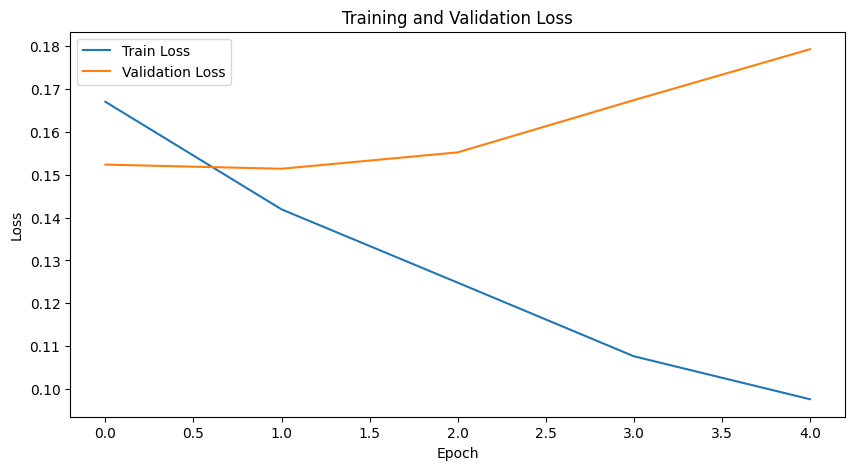

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Drop and Rescale (DARE) Algorithm

In [14]:
# Fuse PEFT config with base model for mergekit
base_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct",
                                                  device_map="auto",
                                                  dtype=torch.float16)
peft_model = PeftModel.from_pretrained(base_model, 'anirvankrishna/model_sft_lora')

fused_model = peft_model.merge_and_unload()
fused_model.push_to_hub("anirvankrishna/model_sft_lora_fused")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/5.99M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...7uef0l8/model.safetensors:   4%|4         |  128MB / 3.09GB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/anirvankrishna/model_sft_lora_fused/commit/ae75f2f866ec5d7b77bc3626871c9fd4a7bd4921', commit_message='Upload Qwen2ForCausalLM', commit_description='', oid='ae75f2f866ec5d7b77bc3626871c9fd4a7bd4921', pr_url=None, repo_url=RepoUrl('https://huggingface.co/anirvankrishna/model_sft_lora_fused', endpoint='https://huggingface.co', repo_type='model', repo_id='anirvankrishna/model_sft_lora_fused'), pr_revision=None, pr_num=None)

In [15]:
def merge_models(p_dropout: float, lamda: float, output_path: str):
    """
    Merges a base model and a PEFT model using DARE-TIES.

    Args:
        p_dropout: The fraction of weights to drop (e.g., 0.9)
        lamda: The scaling factor for the merged weights (e.g., 1.0)
        output_path: Where to save the resulting safetensors.
    """

    # Mergekit's 'density' is the fraction of weights we KEEP.
    keep_density = 1.0 - p_dropout

    config_dict = {
        "models": [
            {
                "model": "Qwen/Qwen2.5-1.5B-Instruct"  # The Base Model
            },
            {
                # Mergekit automatically detects this is PEFT
                "model": "anirvankrishna/model_sft_lora_fused",
                "parameters": {
                    "density": keep_density,
                    "weight": lamda
                }
            }
        ],
        "merge_method": "dare_ties",
        "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
        "dtype": "bfloat16",
        "chat_template": "chatml"    # Qwen chat template
    }

    merge_config = MergeConfiguration.model_validate(config_dict)

    options = MergeOptions(
        lora_merge_cache="/tmp",
        cuda=torch.cuda.is_available(),
        copy_tokenizer=True,
        lazy_unpickle=False,
        low_cpu_memory=False
    )

    # If the output directory already exists (from a previous loop iteration), clear it
    if os.path.exists(output_path):
        shutil.rmtree(output_path)

    run_merge(
        merge_config,
        out_path=output_path,
        options=options
    )

    return output_path

In [20]:
def evaluate_model(model_path: str,
                   tokenizer_path: str = "anirvankrishna/model_sft_lora",
                   validation_dataloader=val_dataloader,
                   device=device):
    """
    Evaluates a merged model on the validation set and returns the BLEU score.
    """

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)

    # CRITICAL: Batched generation requires left-padding
    tokenizer.padding_side = 'left'
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path, device_map="auto", dtype=torch.bfloat16)
    model.to(device)
    model.eval()

    references = []
    predictions = []

    with torch.no_grad():
        for batch in tqdm(validation_dataloader, desc="Validation"):

            encodings = tokenizer(batch["prompt"], padding=True, truncation=True, return_tensors="pt")
            input_ids = encodings.input_ids.to(device)
            attention_mask = encodings.attention_mask.to(device)

            with autocast(device_type=device.type):
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_new_tokens=128,
                    pad_token_id=tokenizer.pad_token_id
                )

            prompt_lengths = input_ids.shape[1]
            new_tokens = generated_ids[:, prompt_lengths:]

            decoded_preds = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

            decoded_refs = []
            for full_text, prompt in zip(batch["full_text"], batch["prompt"]):
                target = full_text.replace(prompt, "").strip()
                decoded_refs.append(target)

            predictions.extend([pred.strip() for pred in decoded_preds])
            references.extend([[ref] for ref in decoded_refs])

    # Calculate BLEU score
    bleu = evaluate.load("sacrebleu")

    bleu_score = bleu.compute(predictions=predictions, references=references)["score"]

    return bleu_score

In [21]:
dropouts = [0.1, 0.3, 0.5, 0.7]
lambdas = [0.8, 1.0, 1.2]
bleu_scores = {}

best_score = -float('inf')
temp_merge_dir = "./temp_dare_merge"
final_best_dir = "./anirvankrishna_best_dare_model"

for p in dropouts:
    for l in lambdas:

        merge_models(p_dropout=p, lamda=l, output_path=temp_merge_dir)
        score = evaluate_model(temp_merge_dir)

        print(f"Score for p={p}, l={l}: {score}")
        bleu_scores[(p, l)] = score

        # 3. If it's the best, copy it to the permanent directory
        if score > best_score:
            best_score = score
            print(f"New best model found! Saving to {final_best_dir}")

            if os.path.exists(final_best_dir):
                shutil.rmtree(final_best_dir)

            # Copy the winning files over
            shutil.copytree(temp_merge_dir, final_best_dir)


# Tabulate results
table_data = []
for (p, l), score in bleu_scores.items():
    table_data.append([p, l, score])

print(tabulate(table_data, headers=["Dropout (p)", "Lambda", "BLEU Score"], tablefmt="grid"))

print(f"Grid search complete! Best score: {best_score}")

Executing graph: 100%|██████████| 1692/1692 [00:02<00:00, 745.13it/s] 


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Validation: 100%|██████████| 255/255 [01:10<00:00,  3.61it/s]


...

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Validation: 100%|██████████| 255/255 [01:09<00:00,  3.67it/s]


Score for p=0.7, l=1.2: 15.284617850945569
+---------------+----------+--------------+
|   Dropout (p) |   Lambda |   BLEU Score |
+===============+==========+==============+
|           0.1 |      0.8 |      15.1517 |
+---------------+----------+--------------+
|           0.1 |      1   |      15.2017 |
+---------------+----------+--------------+
|           0.1 |      1.2 |      15.1543 |
+---------------+----------+--------------+
|           0.3 |      0.8 |      15.2664 |
+---------------+----------+--------------+
|           0.3 |      1   |      15.1203 |
+---------------+----------+--------------+
|           0.3 |      1.2 |      15.1167 |
+---------------+----------+--------------+
|           0.5 |      0.8 |      15.1706 |
+---------------+----------+--------------+
|           0.5 |      1   |      15.2043 |
+---------------+----------+--------------+
|           0.5 |      1.2 |      15.3451 |
+---------------+----------+--------------+
|           0.7 |      0.8 |     